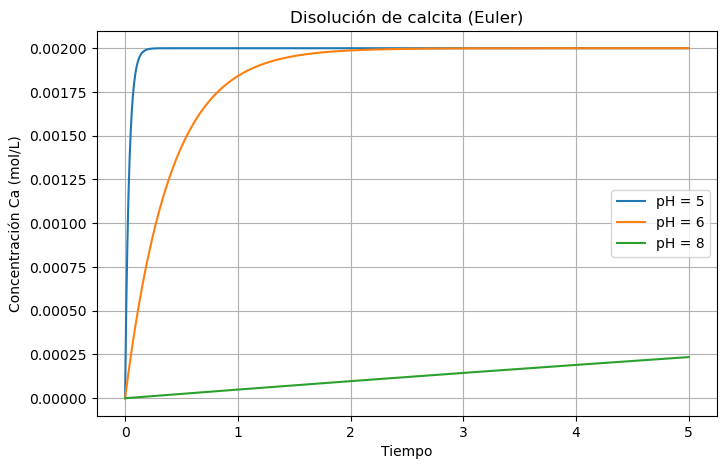

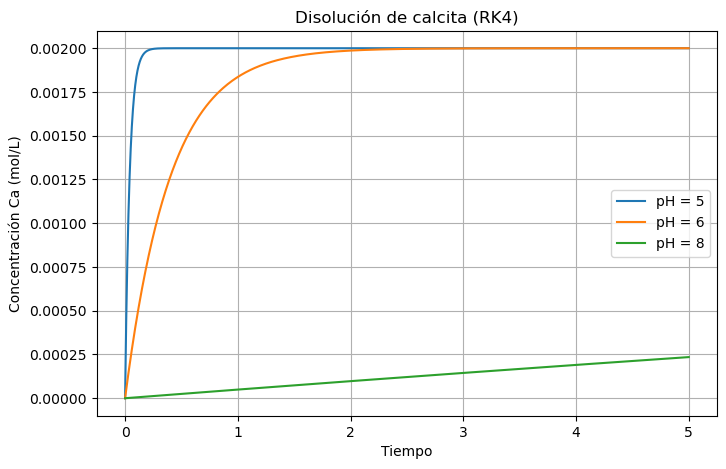

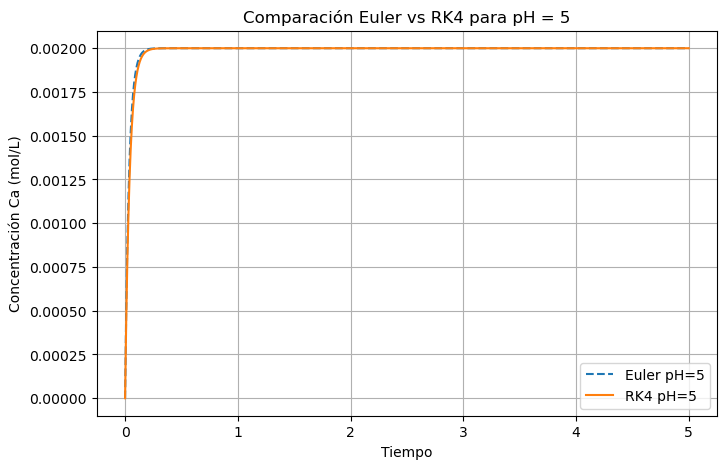

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del modelo
kH = 5e3
Ceq = 2e-3
C0 = 0.0

# Ecuación diferencial
def dCdt(C, pH):
    rate = kH * 10**(-pH)
    return rate * (1 - C / Ceq)

# Paso de Euler
def euler_step(C, dt, pH):
    return C + dt * dCdt(C, pH)

# Paso de RK4
def rk4_step(C, dt, pH):
    k1 = dCdt(C, pH)
    k2 = dCdt(C + 0.5 * dt * k1, pH)
    k3 = dCdt(C + 0.5 * dt * k2, pH)
    k4 = dCdt(C + dt * k3, pH)
    return C + dt * (k1 + 2*k2 + 2*k3 + k4) / 6

# Simulación
dt = 0.01
tmax = 5
time = np.arange(0, tmax + dt, dt)

pH_values = [5, 6, 8]

results_euler = {}
results_rk4 = {}

for pH in pH_values:
    C = C0
    C_values = [C0]
    for _ in range(len(time) - 1):
        C = euler_step(C, dt, pH)
        C_values.append(C)
    results_euler[pH] = np.array(C_values)

for pH in pH_values:
    C = C0
    C_values = [C0]
    for _ in range(len(time) - 1):
        C = rk4_step(C, dt, pH)
        C_values.append(C)
    results_rk4[pH] = np.array(C_values)

# Gráfica Euler
plt.figure(figsize=(8,5))
for pH in pH_values:
    plt.plot(time, results_euler[pH], label=f"pH = {pH}")

plt.xlabel("Tiempo")
plt.ylabel("Concentración Ca (mol/L)")
plt.title("Disolución de calcita (Euler)")
plt.legend()
plt.grid(True)
plt.show()

# Gráfica RK4
plt.figure(figsize=(8,5))
for pH in pH_values:
    plt.plot(time, results_rk4[pH], label=f"pH = {pH}")

plt.xlabel("Tiempo")
plt.ylabel("Concentración Ca (mol/L)")
plt.title("Disolución de calcita (RK4)")
plt.legend()
plt.grid(True)
plt.show()

# Comparación Euler vs RK4 para pH=5
plt.figure(figsize=(8,5))
plt.plot(time, results_euler[5], '--', label="Euler pH=5")
plt.plot(time, results_rk4[5], label="RK4 pH=5")

plt.xlabel("Tiempo")
plt.ylabel("Concentración Ca (mol/L)")
plt.title("Comparación Euler vs RK4 para pH = 5")
plt.legend()
plt.grid(True)
plt.show()

### Comparación de las curvas obtenidas

Las curvas obtenidas muestran que la concentración de calcio aumenta con el tiempo debido a la disolución de la calcita, pero la rapidez con la que aumenta depende del pH. Se observa que para **pH = 5** la concentración crece más rápidamente, para **pH = 6** el aumento es moderado y para **pH = 8** el crecimiento es mucho más lento. Esto indica que la velocidad de disolución de la calcita disminuye a medida que aumenta el pH.

**a) ¿Cómo afecta el pH la velocidad de disolución de calcita?**  

El pH afecta inversamente la velocidad de disolución de la calcita. A valores bajos de pH, la disolución ocurre más rápido, mientras que a valores altos ocurre más lentamente. En este modelo, esto se debe a que la velocidad depende del término $10^{-pH}$, el cual es mayor cuando el pH es menor.

**b) ¿Por qué la disolución es más rápida a pH bajos?**  

La disolución es más rápida a pH bajos porque en un medio ácido hay mayor concentración de iones hidrógeno ($H^+$). Estos protones reaccionan más fácilmente con la calcita y favorecen su disolución, acelerando la liberación de calcio hacia la solución.

**c) ¿Qué ocurre cuando $C$ se aproxima a $C_{eq}$?**  

Cuando la concentración $C$ se aproxima a la concentración de equilibrio $C_{eq}$, la velocidad de disolución disminuye progresivamente. Esto sucede porque el término:

$$
\left(1 - \frac{C}{C_{eq}}\right)
$$

se hace cada vez más pequeño. Cuando $C$ es casi igual a $C_{eq}$, el sistema se acerca al equilibrio y la disolución prácticamente se detiene.

### Efecto del paso temporal $\Delta t$ en la estabilidad del modelo

El paso temporal $\Delta t$ influye en la estabilidad y precisión del modelo numérico. Cuando se usa un valor pequeño de $\Delta t$, la solución es más estable y representa mejor el comportamiento real del sistema. En cambio, si se usa un paso temporal muy grande, pueden aparecer errores numéricos, especialmente con el método de Euler, haciendo que la solución pierda precisión o incluso se vuelva inestable. Por esta razón, un $\Delta t$ pequeño mejora la calidad del resultado, y además el método RK4 suele ser más preciso y estable que Euler para el mismo paso temporal.